Image Classification using CNN Architectures
| Assignment


Q1. What is a Convolutional Neural Network (CNN), and how does it differ from
traditional fully connected neural networks in terms of architecture and performance on
image data?

A1. A Convolutional Neural Network is a deep learning model specially designed for processing image data. CNNs use convolution and pooling layers to automatically extract features such as edges, textures, and shapes from images. Unlike traditional fully connected neural networks, CNNs use local connections and shared weights, which reduce the number of parameters and improve performance and accuracy on image classification tasks.

Q2. Discuss the architecture of LeNet-5 and explain how it laid the foundation
for modern deep learning models in computer vision. Include references to its original
research paper.

A2. LeNet-5 is one of the earliest CNN architectures developed by Yann LeCun for handwritten digit recognition. Its architecture consists of convolution layers, average pooling layers, and fully connected layers. LeNet-5 takes a 32×32 grayscale image as input and performs feature extraction followed by classification. It introduced important concepts such as convolution, weight sharing, and pooling, which became the foundation of modern computer vision models like AlexNet and VGG. The original research paper is Gradient-Based Learning Applied to Document Recognition (1998) by Yann LeCun et al.

Q3. Compare and contrast AlexNet and VGGNet in terms of design principles,
number of parameters, and performance. Highlight key innovations and limitations of
each.

A3. AlexNet and VGG are important CNN architectures used for image classification. AlexNet contains 8 layers and introduced key innovations such as ReLU activation, dropout, and GPU training, which improved deep learning performance significantly. It uses larger filters like 11×11 and has fewer parameters compared to VGGNet.

VGGNet is deeper, containing 16–19 layers, and uses only small 3×3 filters throughout the network. This simple and uniform design improved feature extraction and achieved higher accuracy than AlexNet, but it has a very large number of parameters and requires high computational power and memory.

Q4. What is transfer learning in the context of image classification? Explain
how it helps in reducing computational costs and improving model performance with
limited data.


A4. Transfer learning is a deep learning technique in which a model trained on a large image dataset is reused for a new image classification task. Pre-trained models such as ResNet or VGGNet already learn important image features like edges, textures, and shapes.

Instead of training from scratch, only the final layers are retrained for the new task. This reduces computational cost, training time, and hardware requirements. It also improves model performance and accuracy when only a small amount of labeled data is available.

Q5. Describe the role of residual connections in ResNet architecture. How do
they address the vanishing gradient problem in deep CNNs?

A5. Residual connections in ResNet allow the input of a layer to skip directly to deeper layers through shortcut connections. Instead of learning the complete mapping, the network learns the residual (difference) between input and output.

These connections help gradients flow easily during backpropagation, reducing the vanishing gradient problem in very deep CNNs. As a result, ResNet can train deeper networks effectively while improving accuracy and convergence.

Q6. Implement the LeNet-5 architectures using Tensorflow or PyTorch to
classify the MNIST dataset. Report the accuracy and training time.

In [13]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Pad from 28x28 to 32x32 for LeNet-5
x_train = tf.pad(x_train[..., tf.newaxis], [[0, 0], [2, 2], [2, 2], [0, 0]])
x_test = tf.pad(x_test[..., tf.newaxis], [[0, 0], [2, 2], [2, 2], [0, 0]])

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# LeNet-5 model
model = models.Sequential([
    layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=(32, 32, 1), padding='valid'),
    layers.AveragePooling2D(pool_size=2, strides=2),

    layers.Conv2D(16, kernel_size=5, activation='tanh', padding='valid'),
    layers.AveragePooling2D(pool_size=2, strides=2),

    layers.Conv2D(120, kernel_size=5, activation='tanh', padding='valid'),

    layers.Flatten(),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train and measure time
start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

training_time = time.time() - start_time

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8992 - loss: 0.3533 - val_accuracy: 0.9630 - val_loss: 0.1377
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9610 - loss: 0.1309 - val_accuracy: 0.9767 - val_loss: 0.0826
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0820 - val_accuracy: 0.9795 - val_loss: 0.0664
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9813 - loss: 0.0606 - val_accuracy: 0.9823 - val_loss: 0.0623
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9853 - loss: 0.0473 - val_accuracy: 0.9850 - val_loss: 0.0517

Test Accuracy: 98.26%
Training Time: 14.42 seconds


Q7. Use a pre-trained VGG16 model (via transfer learning) on a small custom
dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
Include your code and result discussion.


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [15]:
import os

print(os.listdir(path))

['test_set', 'training_set']


In [16]:
import os
import shutil
import random

source_dir = path

base_dir = "/content/dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

classes = ["cats", "dogs"]

for split in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

# Original dataset folders
cat_files = os.listdir(os.path.join(source_dir, "training_set", "training_set", "cats"))
dog_files = os.listdir(os.path.join(source_dir, "training_set", "training_set", "dogs"))

random.shuffle(cat_files)
random.shuffle(dog_files)

# Small dataset for assignment
cat_train = cat_files[:50]
cat_val = cat_files[50:60]
cat_test = cat_files[60:70]

dog_train = dog_files[:50]
dog_val = dog_files[50:60]
dog_test = dog_files[60:70]

def copy_files(files, src_folder, dest_folder):
    for file in files:
        shutil.copy(
            os.path.join(src_folder, file),
            os.path.join(dest_folder, file)
        )

# Copy cats
copy_files(cat_train,
           os.path.join(source_dir, "training_set", "training_set", "cats"),
           os.path.join(train_dir, "cats"))

copy_files(cat_val,
           os.path.join(source_dir, "training_set", "training_set", "cats"),
           os.path.join(val_dir, "cats"))

copy_files(cat_test,
           os.path.join(source_dir, "training_set", "training_set", "cats"),
           os.path.join(test_dir, "cats"))

# Copy dogs
copy_files(dog_train,
           os.path.join(source_dir, "training_set", "training_set", "dogs"),
           os.path.join(train_dir, "dogs"))

copy_files(dog_val,
           os.path.join(source_dir, "training_set", "training_set", "dogs"),
           os.path.join(val_dir, "dogs"))

copy_files(dog_test,
           os.path.join(source_dir, "training_set", "training_set", "dogs"),
           os.path.join(test_dir, "dogs"))

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time

train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"
test_dir  = "/content/dataset/test"

img_size = (224, 224)
batch_size = 16

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

end = time.time()

loss, accuracy = model.evaluate(test_data)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Training Time: {end-start:.2f} seconds")

Found 200 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 832ms/step - accuracy: 0.7400 - loss: 1.7672 - val_accuracy: 0.9750 - val_loss: 0.0961
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 232ms/step - accuracy: 0.8600 - loss: 0.8043 - val_accuracy: 0.9000 - val_loss: 0.3298
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.9450 - loss: 0.1884 - val_accuracy: 0.9000 - val_loss: 0.1914
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.9300 - loss: 0.1999 - val_accuracy: 0.9750 - val_loss: 0.0972
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.9700 - loss: 0.1325 - val_accuracy: 0.9750 - val_loss: 0.0506
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9500 - loss: 0.1889

Test Accuracy: 95.00%
Training Time: 34.98 seconds


Q8. Write a program to visualize the filters and feature maps of the first
convolutional layer of AlexNet on an example input image.

Saving dog.webp to dog.webp
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 157MB/s]


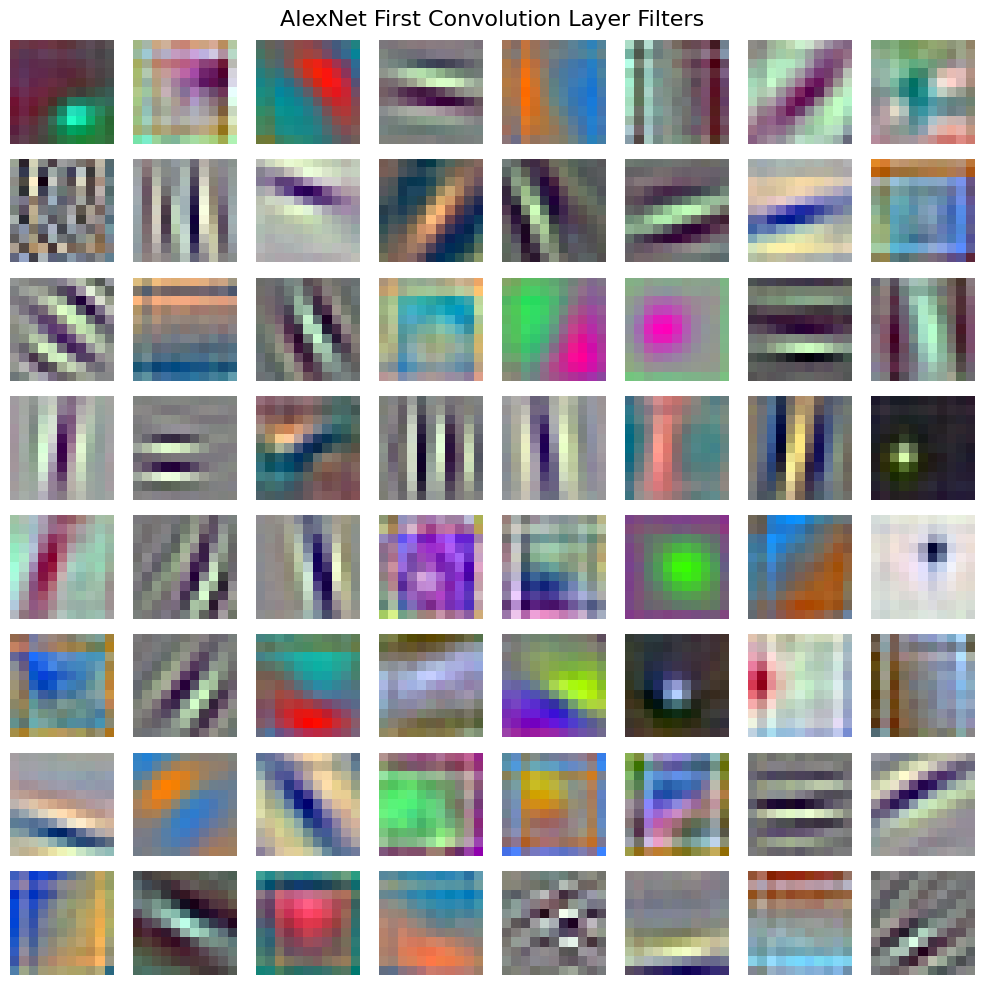

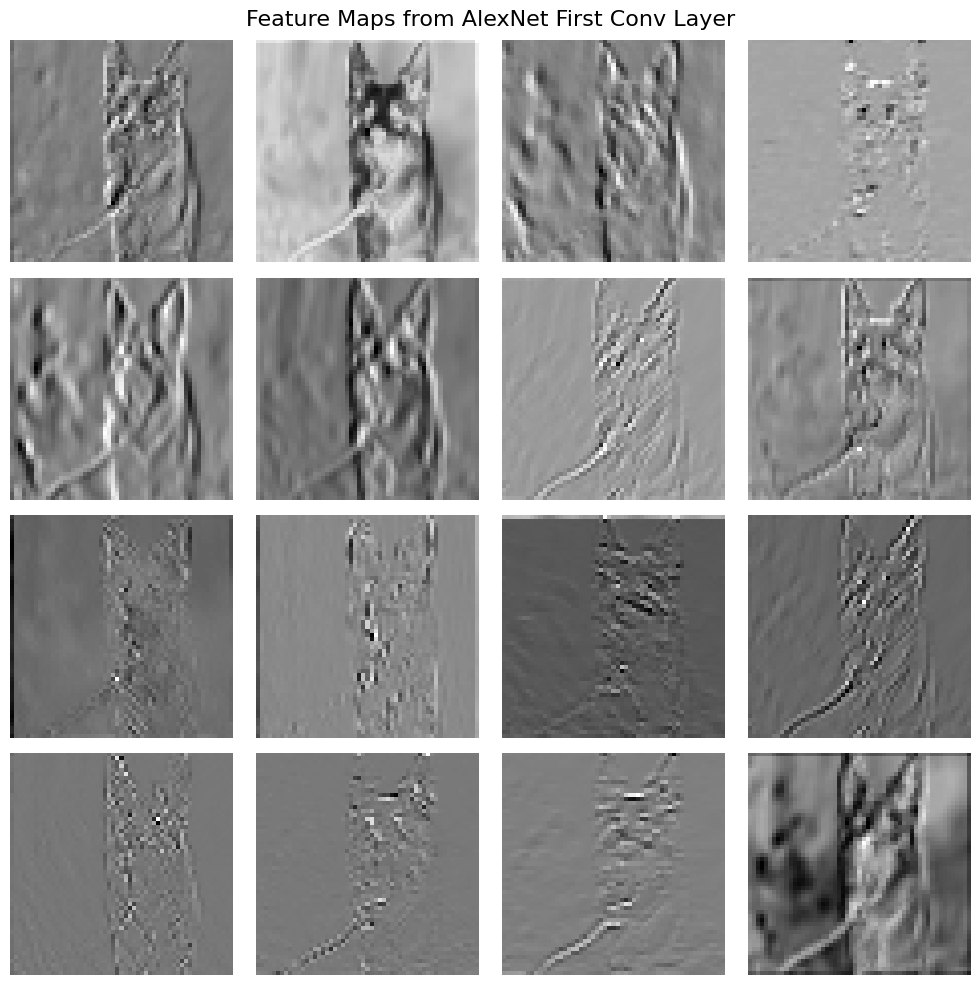

In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

model = torchvision.models.alexnet(weights=torchvision.models.AlexNet_Weights.DEFAULT)
model.eval()

conv1 = model.features[0]

weights = conv1.weight.data.clone()

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle("AlexNet First Convolution Layer Filters", fontsize=16)

for i, ax in enumerate(axes.flat):
    w = weights[i]
    w = w.permute(1, 2, 0)

    w = (w - w.min()) / (w.max() - w.min() + 1e-5)

    ax.imshow(w)
    ax.axis("off")

plt.tight_layout()
plt.show()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    feature_maps = conv1(input_tensor)   # shape: [1, 64, H, W]

feature_maps = feature_maps.squeeze(0)   # [64, H, W]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Feature Maps from AlexNet First Conv Layer", fontsize=16)

for i, ax in enumerate(axes.flat):
    fmap = feature_maps[i].cpu().numpy()
    ax.imshow(fmap, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

The first part visualizes the learned 11×11 convolution filters of AlexNet. The second part shows the feature maps produced when an input image passes through the first convolution layer. These maps capture edges, textures, and simple patterns.

Q9. Train a GoogLeNet (Inception v1) or its variant using a standard dataset
like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
overfitting or underfitting.


Device: cuda


100%|██████████| 170M/170M [09:56<00:00, 286kB/s]


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 155MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch [1/5] Train Loss: 0.9502, Train Acc: 87.64% | Val Loss: 0.1744, Val Acc: 94.18%
Epoch [2/5] Train Loss: 0.3850, Train Acc: 96.29% | Val Loss: 0.1559, Val Acc: 94.86%
Epoch [3/5] Train Loss: 0.2430, Train Acc: 98.48% | Val Loss: 0.1540, Val Acc: 95.00%
Epoch [4/5] Train Loss: 0.1791, Train Acc: 99.19% | Val Loss: 0.1591, Val Acc: 95.28%
Epoch [5/5] Train Loss: 0.1380, Train Acc: 99.37% | Val Loss: 0.1741, Val Acc: 94.94%


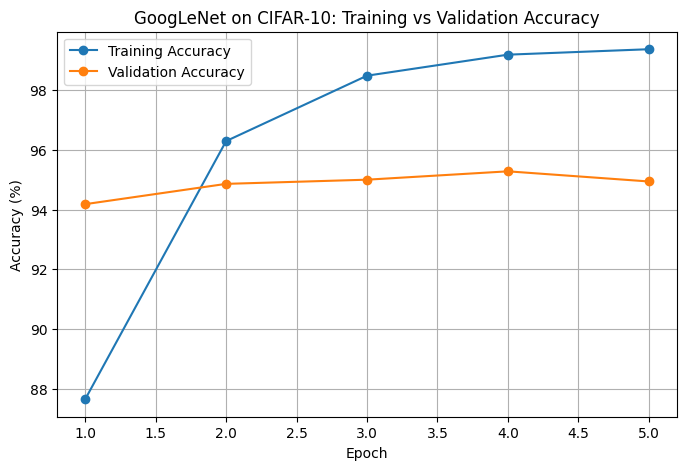

Test Accuracy: 94.58%


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import googlenet, GoogLeNet_Weights
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
])

full_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

weights = GoogLeNet_Weights.DEFAULT
model = googlenet(weights=weights, aux_logits=True)
model.fc = nn.Linear(model.fc.in_features, 10)

model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, 10)
model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, 10)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # GoogLeNet returns auxiliary outputs during training
        loss = criterion(outputs.logits, labels)
        if outputs.aux_logits1 is not None:
            loss += 0.3 * criterion(outputs.aux_logits1, labels)
        if outputs.aux_logits2 is not None:
            loss += 0.3 * criterion(outputs.aux_logits2, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # In eval mode, GoogLeNet returns only logits
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

epochs = 5
train_acc_history = []
val_acc_history = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_acc_history, marker='o', label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_acc_history, marker='o', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("GoogLeNet on CIFAR-10: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.2f}%")

Q10. You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal,
pneumonia, and COVID-19. Due to limited labeled data, what approach would you
suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
or Inception variants)? Justify your approach and outline a deployment strategy for
production use.

A10.

1) I would suggest transfer learning with a ResNet-50 backbone: freeze most layers, replace the final classifier for the 3 classes, then fine-tune the last residual block. ResNet’s residual connections were designed to make very deep CNNs easier to optimize, and medical-imaging transfer learning is especially effective when labeled data is limited.

2) If compute or memory is tighter, Inception is a strong alternative because it was explicitly designed for computational efficiency, but for this use case I would still start with ResNet for a simpler and robust fine-tuning path.

3) For deployment, use an external validation set from another hospital, calibrate confidence thresholds, route uncertain cases to a radiologist, and monitor drift/performance after release. That matches medical ML guidance on representative data, good software/security practice, and total-lifecycle monitoring.





In [20]:
!pip -q install kagglehub

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-pneumonia-normal-chest-xray-pa-dataset' dataset.
Path to dataset files: /kaggle/input/covid19-pneumonia-normal-chest-xray-pa-dataset


Dataset path: /kaggle/input/covid19-pneumonia-normal-chest-xray-pa-dataset

Folders inside dataset:
['pneumonia', 'normal', 'covid']

Class Counts:
class
pneumonia    2313
normal       2313
covid        2276
Name: count, dtype: int64

Train: 4831
Validation: 1035
Test: 1036
Found 4831 validated image filenames belonging to 3 classes.
Found 1035 validated image filenames belonging to 3 classes.
Found 1036 validated image filenames belonging to 3 classes.

Class Indices:
{'covid': 0, 'normal': 1, 'pneumonia': 2}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 174s 526ms/step - accuracy: 0.7812 - loss: 0.5661 - val_accuracy: 0.9072 - val_loss: 0.2983 - learning_rate: 1.0000e-04
Epoch 2/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 124s 410ms/step - accuracy: 0.8762 - loss: 0.3501 - val_accuracy: 0.9227 - val_loss: 0.2442 - learning_rate: 1.0000e-04
Epoch 3/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 123s 405ms/step - accuracy: 0.8971 - loss: 0.2969 - val_accuracy: 0.9159 - val_loss: 0.2356 - learning_rate: 1.0000e-04
Epoch 4/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 123s 406ms/step - accuracy: 0.9095 - loss: 0.2698 - val_accuracy: 0.9314 - val_loss: 0.2056 - learning_rate: 1.0000e-04
Epoch 5/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 123s 408ms/step - accuracy: 0.9108 - loss: 0.2537 - val_accuracy: 0.9382 - val_loss: 0.1922 - learning_rate: 1.0000e-04
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 332ms/step - accuracy: 0.9469 - loss: 0.1832

Test Accuracy: 94.69%
Training Time: 669.41 seconds
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 280ms/step

Classification Report:
          

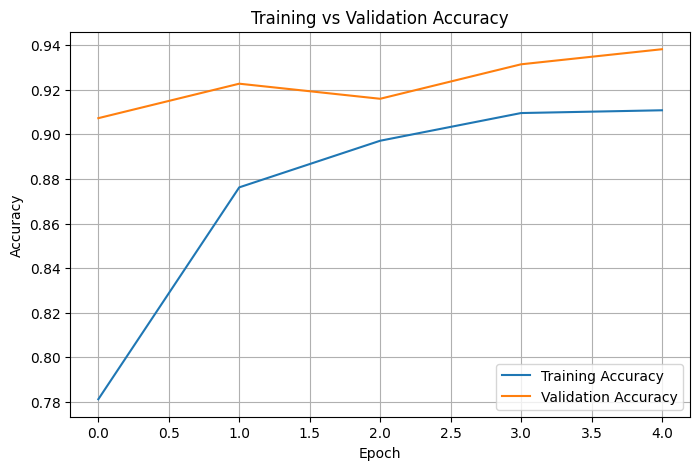

In [22]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Dataset path:", path)
print("\nFolders inside dataset:")
print(os.listdir(path))

IMG_EXTS = (".png", ".jpg", ".jpeg")

image_paths = []
labels = []

for root, dirs, files in os.walk(path):

    folder_name = os.path.basename(root).lower()

    if "covid" in folder_name:
        label = "covid"

    elif "normal" in folder_name:
        label = "normal"

    elif "pneumonia" in folder_name:
        label = "pneumonia"

    else:
        continue

    for file in files:
        if file.lower().endswith(IMG_EXTS):

            image_paths.append(os.path.join(root, file))
            labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "class": labels
})

print("\nClass Counts:")
print(df["class"].value_counts())

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

img_size = (224, 224)
batch_size = 16

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_data = test_gen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_data = test_gen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_data.class_indices)

print("\nClass Indices:")
print(train_data.class_indices)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

training_time = time.time() - start_time

loss, accuracy = model.evaluate(test_data)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

pred_probs = model.predict(test_data)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()